Frequência do sinal ajustada para: 99.61 Hz (bin 51 para NFFT=512)
Calculando limiar da MSC para PFA = 0.05 (H0)...
  H0 trial 5000/50000
  H0 trial 10000/50000
  H0 trial 15000/50000
  H0 trial 20000/50000
  H0 trial 25000/50000
  H0 trial 30000/50000
  H0 trial 35000/50000
  H0 trial 40000/50000
  H0 trial 45000/50000
  H0 trial 50000/50000
Limiar MSC determinado: 0.2853 (Tempo H0: 26.23s)
Calculando PD para diferentes SNRs (H1)...
  SNR por bin = -30.0 dB: PD = 0.049 (IC 95%: [0.043, 0.055]) (Tempo: 2.48s)
  SNR por bin = -29.0 dB: PD = 0.045 (IC 95%: [0.040, 0.052]) (Tempo: 2.49s)
  SNR por bin = -28.0 dB: PD = 0.049 (IC 95%: [0.044, 0.056]) (Tempo: 2.65s)
  SNR por bin = -27.0 dB: PD = 0.047 (IC 95%: [0.041, 0.053]) (Tempo: 2.60s)
  SNR por bin = -26.0 dB: PD = 0.055 (IC 95%: [0.049, 0.062]) (Tempo: 2.58s)
  SNR por bin = -25.0 dB: PD = 0.053 (IC 95%: [0.047, 0.059]) (Tempo: 2.58s)
  SNR por bin = -24.0 dB: PD = 0.053 (IC 95%: [0.047, 0.059]) (Tempo: 2.53s)
  SNR por bin = -23.0 d

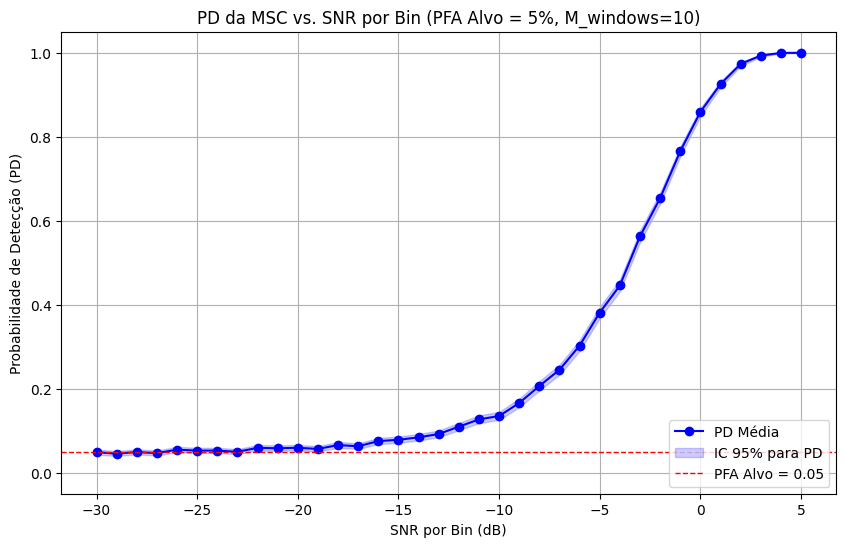

Simulação concluída.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time # Para medir o tempo

# --- Funções Auxiliares ---
def msc_fft_py(Y_input, M_win):
    """
    Calcula a Magnitude Squared Coherence (MSC).
    Y_input: array 2D de FFTs (Nfreqs x M_windows)
    M_win: número de janelas
    """
    if Y_input.shape[1] == 0 or M_win == 0:
        return np.zeros(Y_input.shape[0])

    current_M_win = M_win
    if current_M_win > Y_input.shape[1]:
        current_M_win = Y_input.shape[1]
        if current_M_win == 0:
            return np.zeros(Y_input.shape[0])

    if current_M_win == 1:
        return np.ones(Y_input.shape[0])

    Y_to_use = Y_input[:, :current_M_win]
    
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    
    msc = np.zeros_like(numerator, dtype=float)
    # Evitar divisão por zero e NaNs
    valid_den = denominator != 0
    msc[valid_den] = numerator[valid_den] / denominator[valid_den]
    msc[np.isnan(msc)] = 0
    msc[np.isinf(msc)] = 0
    return msc

def wilson_score_interval_py(k, n, confidence_level=0.95):
    """ Calcula o intervalo de confiança de Wilson para uma proporção. """
    if n == 0:
        return np.nan, (np.nan, np.nan)
    
    alpha = 1 - confidence_level
    z = norm.ppf(1 - alpha / 2) # Valor crítico z
    
    phat = k / n
    
    term1 = phat + (z**2) / (2 * n)
    term2 = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    
    pci_lower = (term1 - term2) / denominator
    pci_upper = (term1 + term2) / denominator
    
    pci_lower = max(0, pci_lower)
    pci_upper = min(1, pci_upper)
    
    return phat, (pci_lower, pci_upper)

# --- Parâmetros da Simulação ---
FS = 1000  # Taxa de amostragem (Hz)
NFFT_msc = 512  # Tamanho da FFT para MSC e para definir SNR por bin
M_windows = 10  # Número de janelas para MSC
f_signal = 100  # Frequência do sinal (Hz)

target_pfa = 0.05  # PFA alvo
N_trials_H0 = 50000  # Trials para estimar limiar H0
N_trials_H1 = 5000  # Trials por SNR para estimar PD H1

snr_db_per_bin_range = np.arange(-30, 5 + 1, 1)  # SNR por bin em dB

total_samples_msc = NFFT_msc * M_windows
t_msc_segment = np.arange(NFFT_msc) / FS

signal_bin_ideal_idx_msc = int(round(f_signal * NFFT_msc / FS))
f_signal_adjusted = signal_bin_ideal_idx_msc * FS / NFFT_msc
print(f'Frequência do sinal ajustada para: {f_signal_adjusted:.2f} Hz (bin {signal_bin_ideal_idx_msc} para NFFT={NFFT_msc})')
# Índice para arrays Python (0-indexado) para espectro unilateral rfft
# Se f_signal > 0, msc_signal_bin_py_idx = signal_bin_ideal_idx_msc
msc_signal_bin_py_idx = signal_bin_ideal_idx_msc


# --- Parte 1: Determinação do Limiar da MSC (H0) ---
print(f'Calculando limiar da MSC para PFA = {target_pfa:.2f} (H0)...')
start_time_h0 = time.time()
msc_values_H0 = np.zeros(N_trials_H0)
sigma_n_sq_time = 1.0

hanning_window = np.hanning(NFFT_msc)

for i in range(N_trials_H0):
    noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
    
    Y_fft_H0_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
    for k in range(M_windows):
        start_idx = k * NFFT_msc
        end_idx = (k + 1) * NFFT_msc
        window_data = noise_all_windows_H0[start_idx:end_idx]
        fft_window = np.fft.rfft(window_data * hanning_window) # Usar rfft
        Y_fft_H0_all_windows[:, k] = fft_window
        
    msc_spectrum_H0 = msc_fft_py(Y_fft_H0_all_windows, M_windows)
    if msc_spectrum_H0 is not None and len(msc_spectrum_H0) > msc_signal_bin_py_idx:
        msc_values_H0[i] = msc_spectrum_H0[msc_signal_bin_py_idx]
    else:
        msc_values_H0[i] = np.nan
        
    if (i + 1) % (N_trials_H0 // 10) == 0:
        print(f'  H0 trial {i+1}/{N_trials_H0}')

msc_values_H0 = msc_values_H0[~np.isnan(msc_values_H0)]
threshold_msc = scoreatpercentile(msc_values_H0, (1 - target_pfa) * 100)
end_time_h0 = time.time()
print(f'Limiar MSC determinado: {threshold_msc:.4f} (Tempo H0: {end_time_h0 - start_time_h0:.2f}s)')


# --- Parte 2: Cálculo da PD e Intervalo de Confiança (H1) ---
pd_values = np.zeros(len(snr_db_per_bin_range))
pd_ic_lower = np.zeros(len(snr_db_per_bin_range))
pd_ic_upper = np.zeros(len(snr_db_per_bin_range))

P_n_bin_expected = (2.0 / NFFT_msc) * sigma_n_sq_time

print('Calculando PD para diferentes SNRs (H1)...')
start_time_h1_total = time.time()

for snr_idx, current_snr_db in enumerate(snr_db_per_bin_range):
    start_time_snr = time.time()
    current_snr_linear = 10**(current_snr_db / 10)
    
    P_s_bin_target = current_snr_linear * P_n_bin_expected
    A_signal = np.sqrt(2 * P_s_bin_target)
    
    detections_H1 = 0
    s_t_single_window = A_signal * np.sin(2 * np.pi * f_signal_adjusted * t_msc_segment)
    # Replicar sinal para todas as janelas
    s_t_all_windows = np.tile(s_t_single_window, M_windows)

    for i in range(N_trials_H1):
        n_t_all_windows = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
        x_t_all_windows = s_t_all_windows + n_t_all_windows
        
        Y_fft_H1_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
        for k in range(M_windows):
            start_idx = k * NFFT_msc
            end_idx = (k + 1) * NFFT_msc
            window_data = x_t_all_windows[start_idx:end_idx]
            fft_window = np.fft.rfft(window_data * hanning_window)
            Y_fft_H1_all_windows[:, k] = fft_window
            
        msc_spectrum_H1 = msc_fft_py(Y_fft_H1_all_windows, M_windows)
        
        current_msc_value = np.nan
        if msc_spectrum_H1 is not None and len(msc_spectrum_H1) > msc_signal_bin_py_idx:
            current_msc_value = msc_spectrum_H1[msc_signal_bin_py_idx]

        if not np.isnan(current_msc_value) and current_msc_value > threshold_msc:
            detections_H1 += 1
            
    pd_val, (ic_low, ic_upp) = wilson_score_interval_py(detections_H1, N_trials_H1)
    pd_values[snr_idx] = pd_val
    pd_ic_lower[snr_idx] = ic_low
    pd_ic_upper[snr_idx] = ic_upp
    
    end_time_snr = time.time()
    print(f'  SNR por bin = {current_snr_db:.1f} dB: PD = {pd_values[snr_idx]:.3f} '
          f'(IC 95%: [{pd_ic_lower[snr_idx]:.3f}, {pd_ic_upper[snr_idx]:.3f}]) '
          f'(Tempo: {end_time_snr - start_time_snr:.2f}s)')

end_time_h1_total = time.time()
print(f'Tempo total H1: {end_time_h1_total - start_time_h1_total:.2f}s')

# --- Parte 3: Plotagem ---
plt.figure(figsize=(10, 6))
plt.plot(snr_db_per_bin_range, pd_values, 'b-o', linewidth=1.5, label='PD Média')
plt.fill_between(snr_db_per_bin_range, pd_ic_lower, pd_ic_upper,
                 color='blue', alpha=0.2, label='IC 95% para PD')
plt.axhline(target_pfa, color='r', linestyle='--', linewidth=1,
            label=f'PFA Alvo = {target_pfa:.2f}')
# plt.axhline(1 - target_pfa, color='k', linestyle=':', label='1 - PFA Alvo')

plt.xlabel('SNR por Bin (dB)')
plt.ylabel('Probabilidade de Detecção (PD)')
plt.title(f'PD da MSC vs. SNR por Bin (PFA Alvo = {target_pfa*100:.0f}%, M_windows={M_windows})')
plt.legend(loc='lower right')
plt.grid(True)
plt.ylim([-0.05, 1.05])
plt.show()

print('Simulação concluída.')